In [1]:
import nltk
from os import getcwd

In [2]:
pip install nltk


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Shyam\Cryptomedbench\tf_env\Scripts\python.exe -m pip install --upgrade pip


In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
import numpy as np
import pandas as pd

In [5]:
train_df= pd.read_csv('PubMed_200k_RCT/train.csv')
dev_df = pd.read_csv('PubMed_200k_RCT/dev.csv')
test_df = pd.read_csv('PubMed_200k_RCT/test.csv')
train_df.head()

,abstract_id,line_id,abstract_text,line_number,total_lines,target
0,24491034,24491034_0_11,The emergence of HIV as a chronic condition me...,0,11,BACKGROUND
1,24491034,24491034_1_11,This paper describes the design and evaluation...,1,11,BACKGROUND
2,24491034,24491034_2_11,This study is designed as a randomised control...,2,11,METHODS
3,24491034,24491034_3_11,The intervention group will participate in the...,3,11,METHODS
4,24491034,24491034_4_11,The program is based on self-efficacy theory a...,4,11,METHODS


In [6]:
# train_df['abstract_text'] = train_df['abstract_text'].fillna('')
# dev_df['abstract_text']   = dev_df['abstract_text'].fillna('')
# test_df['abstract_text']  = test_df['abstract_text'].fillna('')
train_df = train_df.dropna(subset=['abstract_text'])
print(train_df['abstract_text'].isna().sum())
print(dev_df['abstract_text'].isna().sum())
print(test_df['abstract_text'].isna().sum())

0
0
0


In [7]:
print(dev_df.describe())
print(dev_df.info())

        abstract_id   line_number   total_lines
count  2.893200e+04  28932.000000  28932.000000
mean   1.781278e+07      5.676172     12.352343
std    5.356084e+06      3.999521      3.176805
min    1.336526e+06      0.000000      4.000000
25%    1.287862e+07      2.000000     10.000000
50%    1.855817e+07      5.000000     12.000000
75%    2.239816e+07      8.000000     14.000000
max    2.643621e+07     27.000000     28.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28932 entries, 0 to 28931
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abstract_id    28932 non-null  int64 
 1   line_id        28932 non-null  object
 2   abstract_text  28932 non-null  object
 3   line_number    28932 non-null  int64 
 4   total_lines    28932 non-null  int64 
 5   target         28932 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.3+ MB
None


In [8]:
print(test_df.describe())
print(test_df.info())

        abstract_id   line_number   total_lines
count  2.949300e+04  29493.000000  29493.000000
mean   1.773442e+07      5.805344     12.610687
std    5.390987e+06      4.093325      3.279820
min    1.334248e+06      0.000000      4.000000
25%    1.273415e+07      2.000000     10.000000
50%    1.832493e+07      5.000000     12.000000
75%    2.236804e+07      9.000000     14.000000
max    2.642272e+07     27.000000     28.000000
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29493 entries, 0 to 29492
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   abstract_id    29493 non-null  int64 
 1   line_id        29493 non-null  object
 2   abstract_text  29493 non-null  object
 3   line_number    29493 non-null  int64 
 4   total_lines    29493 non-null  int64 
 5   target         29493 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.4+ MB
None


In [9]:
# # Drop the unneccassry column
train_df = train_df.drop(columns=['abstract_id', 'line_id'])
dev_df = dev_df.drop(columns=['abstract_id', 'line_id'])
# med_data_test = med_data_test.drop(columns=['abstract_id', 'line_id'])
dev_df.head()

,abstract_text,line_number,total_lines,target
0,Adrenergic activation is thought to be an impo...,0,9,BACKGROUND
1,Systemic venous norepinephrine was measured at...,1,9,RESULTS
2,Baseline norepinephrine level was associated w...,2,9,RESULTS
3,"On multivariate analysis , baseline norepineph...",3,9,RESULTS
4,"In contrast , the relation of the change in no...",4,9,RESULTS


In [10]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
import re
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')
STOPWORDS = set(stopwords.words('english'))

def process_text(text):
    # Lowercase
    text = text.lower()
    
    # Remove non-alphabetic characters
    text = re.sub(r'[^a-z\s]', ' ', text)
    
    # Tokenize
    tokens = text.split()
    
    # Remove stopwords and short tokens
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]
    
    return tokens

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Shyam\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    tokenizer=process_text,
    ngram_range=(1,3),
    max_features=80000
)

X_train_text = vectorizer.fit_transform(train_df['abstract_text'])
X_dev_text   = vectorizer.transform(dev_df['abstract_text'])

C:\Users\Shyam\Cryptomedbench\tf_env\lib\site-packages\sklearn\feature_extraction\text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


In [13]:
train_rel_pos = (
    train_df['line_number'] / train_df['total_lines']
).values.reshape(-1, 1)

dev_rel_pos = ( 
    dev_df['line_number']/ dev_df['total_lines']
).values.reshape(-1,1)

In [14]:
train_line = train_df['line_number'].values.reshape(-1, 1)
dev_line   = dev_df['line_number'].values.reshape(-1, 1)

In [15]:
from scipy.sparse import hstack
X_train = hstack([X_train_text, train_rel_pos, train_line])
X_dev   = hstack([X_dev_text, dev_rel_pos, dev_line])

In [16]:
print(X_train)

<COOrdinate sparse matrix of dtype 'float64'
	with 39251437 stored elements and shape (2211860, 50002)>
  Coords	Values
  (0, 13740)	0.20583473319237333
  (0, 19529)	0.2993674460897186
  (0, 6835)	0.13526649205549504
  (0, 8350)	0.31828696180931554
  (0, 25990)	0.17164177384989066
  (0, 32212)	0.16185426697734703
  (0, 24579)	0.17675578991350044
  (0, 37848)	0.14962789722786835
  (0, 43874)	0.1941075973867656
  (0, 38185)	0.24876041315625697
  (0, 39788)	0.13482044258140147
  (0, 25327)	0.14064912798665524
  (0, 21079)	0.14211159086482034
  (0, 25259)	0.18852660856910952
  (0, 32886)	0.1366098432317192
  (0, 13774)	0.1840702411360221
  (0, 41324)	0.16159805156691762
  (0, 838)	0.22083877684496234
  (0, 6843)	0.2724680108176995
  (0, 32218)	0.25685018235588636
  (0, 24584)	0.2623756480038936
  (0, 39813)	0.1959186157890575
  (0, 32894)	0.26645605179864557
  (1, 19529)	0.1750843923099253
  (1, 24579)	0.20675046982223558
  :	:
  (2211833, 50001)	10.0
  (2211834, 50001)	11.0
  (2211835, 50

In [17]:
y_train = train_df['target']
y_dev = dev_df['target']

In [18]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_train_enc = label_encoder.fit_transform(y_train)
y_dev_enc   = label_encoder.transform(y_dev)

In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    solver='lbfgs',
    n_jobs=1   # ← FIX
)

model.fit(X_train, y_train_enc)

C:\Users\Shyam\Cryptomedbench\tf_env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [20]:
from sklearn.metrics import classification_report

y_dev_pred = model.predict(X_dev)

print(classification_report(
    y_dev_enc,
    y_dev_pred,
    target_names=label_encoder.classes_
))

              precision    recall  f1-score   support

  BACKGROUND       0.67      0.74      0.70      2575
 CONCLUSIONS       0.88      0.95      0.91      4396
     METHODS       0.92      0.91      0.92      9559
   OBJECTIVE       0.71      0.71      0.71      2425
     RESULTS       0.93      0.88      0.91      9977

    accuracy                           0.88     28932
   macro avg       0.82      0.84      0.83     28932
weighted avg       0.88      0.88      0.88     28932



In [21]:
from scipy.sparse import vstack

X_final = vstack([X_train, X_dev])
y_final = np.concatenate([y_train_enc, y_dev_enc])

model.fit(X_final, y_final)

C:\Users\Shyam\Cryptomedbench\tf_env\lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [22]:
from scipy.sparse import hstack

# TF-IDF features
X_test_text = vectorizer.transform(test_df['abstract_text'])

# Position feature
test_rel_pos = (
    test_df['line_number'] / test_df['total_lines']
).values.reshape(-1, 1)

# Final test feature matrix
test_line   = test_df['line_number'].values.reshape(-1, 1)
X_test = hstack([X_test_text, test_rel_pos, test_line])

In [23]:
y_test = test_df['target']
y_test_enc = label_encoder.transform(y_test)

In [24]:
y_test_pred_enc = model.predict(X_test)

In [25]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Full per-class report
print(classification_report(
    y_test_enc,
    y_test_pred_enc,
    target_names=label_encoder.classes_,
    digits=4
))

# Accuracy
print("Accuracy:", accuracy_score(y_test_enc, y_test_pred_enc))

# Macro metrics (PRIMARY for PubMed RCT)
print("Macro Precision:", precision_score(y_test_enc, y_test_pred_enc, average='macro'))
print("Macro Recall:", recall_score(y_test_enc, y_test_pred_enc, average='macro'))
print("Macro F1:", f1_score(y_test_enc, y_test_pred_enc, average='macro'))

# Weighted metrics (SECONDARY)
print("Weighted F1:", f1_score(y_test_enc, y_test_pred_enc, average='weighted'))

              precision    recall  f1-score   support

  BACKGROUND     0.6862    0.7458    0.7148      2663
 CONCLUSIONS     0.8769    0.9383    0.9066      4426
     METHODS     0.9108    0.9168    0.9138      9751
   OBJECTIVE     0.7133    0.7085    0.7108      2377
     RESULTS     0.9302    0.8768    0.9027     10276

    accuracy                         0.8739     29493
   macro avg     0.8235    0.8372    0.8297     29493
weighted avg     0.8763    0.8739    0.8745     29493

Accuracy: 0.8738683755467399
Macro Precision: 0.8234742670702495
Macro Recall: 0.8372359713565629
Macro F1: 0.829738361079961
Weighted F1: 0.8745198839582939


In [26]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

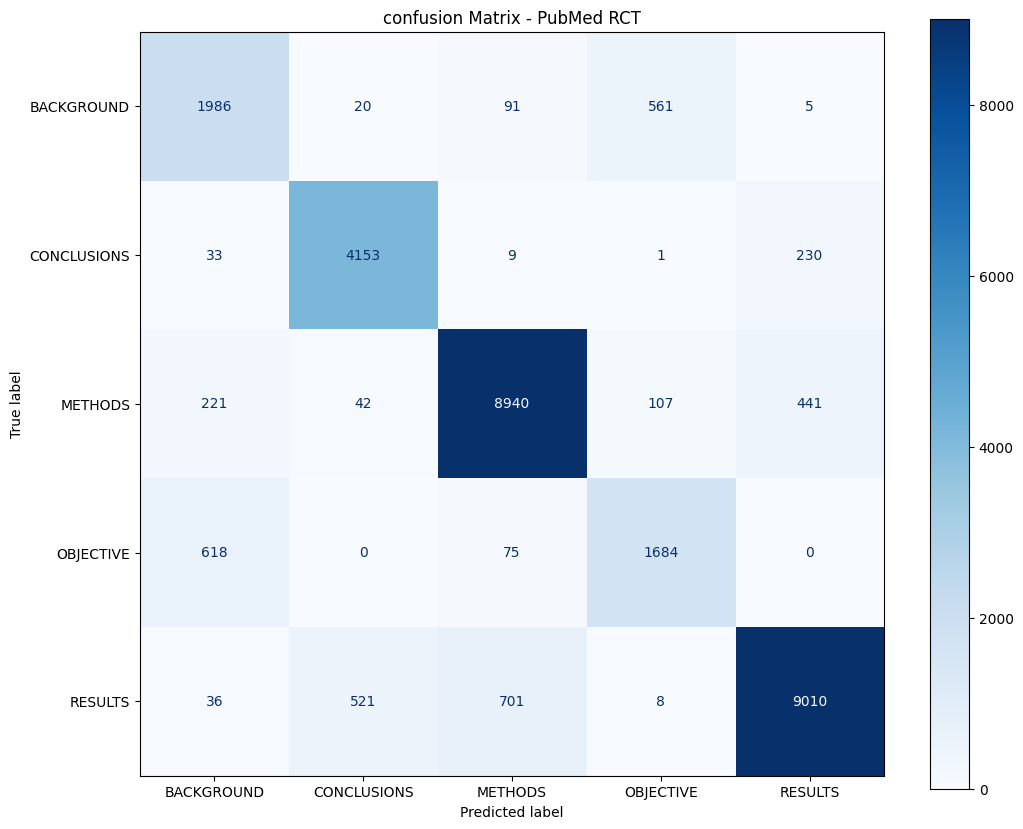

In [27]:
cm = confusion_matrix(y_test_enc, y_test_pred_enc)
disp = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels = label_encoder.classes_)
fig, ax = plt.subplots(figsize = (12,10))
disp.plot(ax = ax, cmap='Blues', values_format='d')
plt.title("confusion Matrix - PubMed RCT")
plt.show()

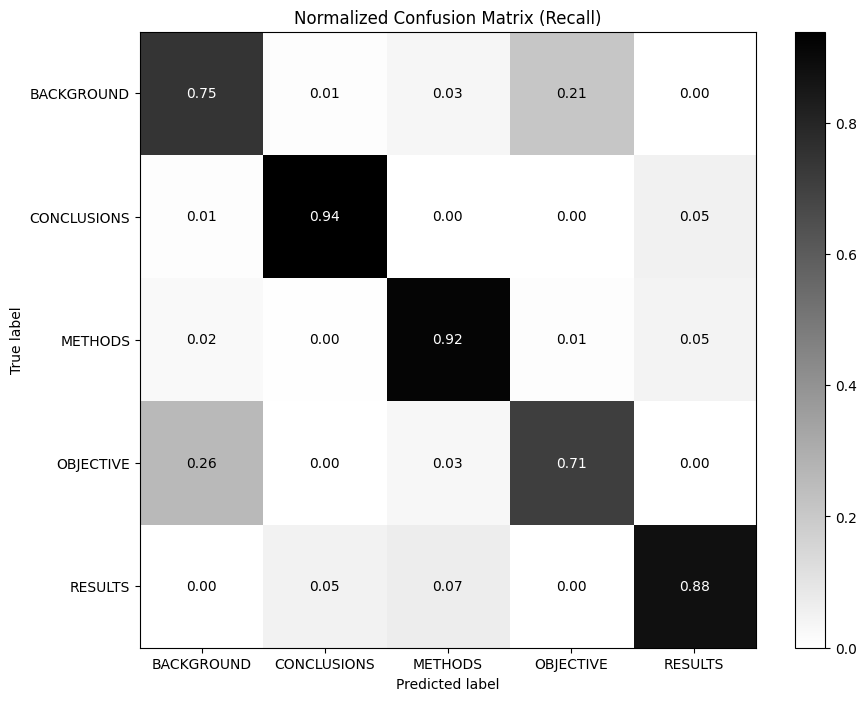

In [28]:
cm_norm = confusion_matrix(
    y_test_enc,
    y_test_pred_enc,
    normalize = 'true')

disp = ConfusionMatrixDisplay(
    confusion_matrix = cm_norm,
    display_labels = label_encoder.classes_)

fig, ax = plt.subplots(figsize= (10,8))
disp.plot(ax = ax, cmap= 'binary', values_format = '.2f')
plt.title("Normalized Confusion Matrix (Recall)")
plt.show()

In [29]:
y_test_proba = model.predict_proba(X_test)

In [30]:
from sklearn.preprocessing import label_binarize
y_test_bin = label_binarize( y_test_enc,
                             classes = np.arange(len(label_encoder.classes_)))

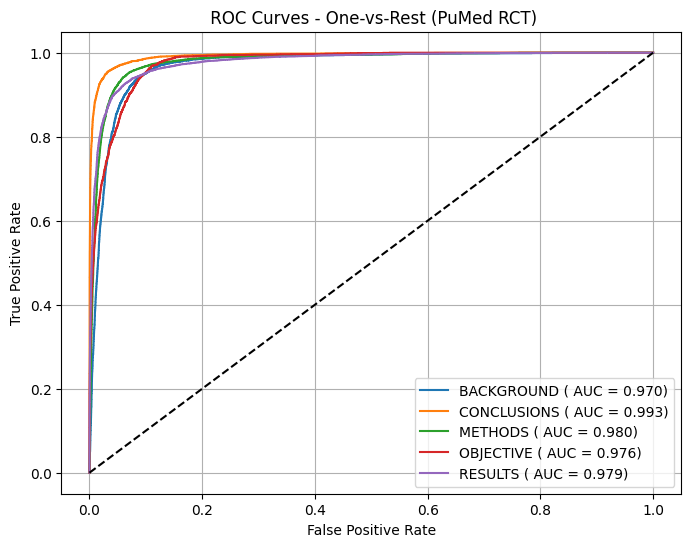

In [31]:
from sklearn.metrics import roc_curve, auc
plt.figure(figsize=(8,6))
for i, class_name in enumerate(label_encoder.classes_):
    fpr, tpr, _ = roc_curve( y_test_bin[:, i], y_test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label = f"{class_name} ( AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(" ROC Curves - One-vs-Rest (PuMed RCT)")
plt.legend(loc = "lower right")
plt.grid(True)
plt.show()

In [32]:
from sklearn.metrics import roc_auc_score
macro_auc = roc_auc_score(
    y_test_bin,
    y_test_proba,
    average = 'macro',
    multi_class = 'ovr')
weighted_auc = roc_auc_score(
    y_test_bin,
    y_test_proba,
    average = 'weighted', 
    multi_class = 'ovr')
print("Macro ROC-AUC:", macro_auc)
print("Weighted ROC-AUC:", weighted_auc)

Macro ROC-AUC: 0.9794025991848937
Weighted ROC-AUC: 0.9801682926788446


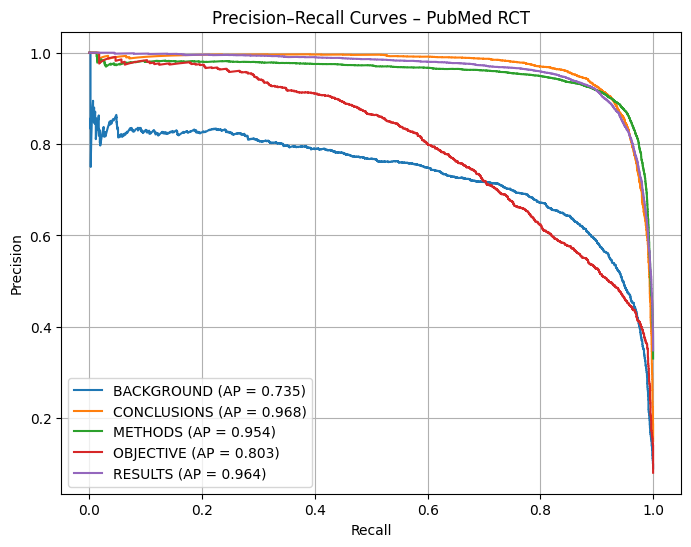

In [33]:
from sklearn.metrics import precision_recall_curve, average_precision_score

plt.figure(figsize=(8, 6))

for i, class_name in enumerate(label_encoder.classes_):
    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_test_proba[:, i]
    )
    ap = average_precision_score(y_test_bin[:, i], y_test_proba[:, i])
    plt.plot(recall, precision, label=f"{class_name} (AP = {ap:.3f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curves – PubMed RCT")
plt.legend()
plt.grid(True)
plt.show()


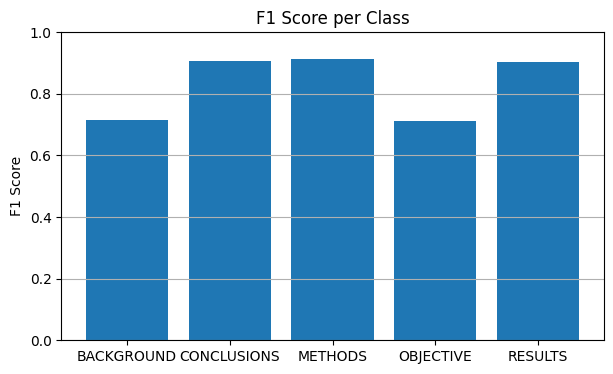

In [34]:
from sklearn.metrics import f1_score

f1_per_class = f1_score(
    y_test_enc,
    y_test_pred_enc,
    average=None
)

plt.figure(figsize=(7, 4))
plt.bar(label_encoder.classes_, f1_per_class)
plt.title("F1 Score per Class")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.grid(axis='y')
plt.show()


In [38]:
pip install joblib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\Shyam\Cryptomedbench\tf_env\Scripts\python.exe -m pip install --upgrade pip


In [39]:
import joblib

# Save
joblib.dump(model, "logreg_model.pkl")

# Load
model = joblib.load("logreg_model.pkl")